In [ ]:
# Good Day! This is John Emmanuel O. Genita's Code. GENITA , TUPM-25-3534
# Calculated Topic: REN-02: Turbulence Load Stress / wind farm telemetry
# Unique Filter Logic : Downtime removal and windshear filter

In [70]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import skew
import os
from IPython.display import display

class WindPowerMasterAnalyzer:
    def __init__(self, file_names):
        self.file_names = file_names
        self.df = None
        self.stats_report = {}

    # --- MODULE 1: DATA INGESTION ---
    def ingest_data(self):
        all_data = []
        for file in self.file_names:
            try:
                print(f"Ingesting: {file}...")
                if not os.path.exists(file):
                    raise FileNotFoundError(f"Path not found: {file}")
                temp_df = pd.read_csv(file)
                temp_df['Location'] = os.path.basename(file).split('.')[0] 
                all_data.append(temp_df)
            except Exception as e:
                print(f"CRITICAL ERROR loading {file}: {e}")
        
        if all_data:
            self.df = pd.concat(all_data, ignore_index=True)
            print(f"Master dataset created: {len(self.df)} rows.")

    # --- MODULE 2: DATA PIPELINE & CLEANING ---
    def clean_and_save(self, output_folder="."):
        if self.df is None: return
        try:
            raw_count = len(self.df)
            
            self.df.dropna(inplace=True)
            self.df.drop_duplicates(inplace=True)
            self.df['Time'] = pd.to_datetime(self.df['Time'])
            for col in ['Power', 'windspeed_100m', 'windspeed_10m']:
                if col in self.df.columns:
                    self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

            # Physics-Based Anomaly Removal
            anomaly_mask = (self.df['windspeed_100m'] > 3.5) & (self.df['Power'] < 0.001)
            self.df = self.df[~anomaly_mask].copy()
            
            print(f"\n--- DATA PURIFICATION LOG ---")
            print(f"Operational Anomalies Purged: {raw_count - len(self.df)}")
            
            # SAVING CSV TO SPECIFIED FOLDER
            save_path = os.path.join(output_folder, 'dataset_cleaned.csv')
            self.df.to_csv(save_path, index=False)
            print(f"File saved: {save_path}")
        except Exception as e:
            print(f"Cleaning Error: {e}")

    # --- MODULE 3: ENGINEERING ANALYTICS ---
    def compute_metrics(self):
        p_vals = self.df['Power'].to_numpy()
        self.stats_report = {
            'Mean': np.mean(p_vals),
            'Median': np.median(p_vals),
            'Std_Dev': np.std(p_vals),
            'Variance': np.var(p_vals),
            'Skewness': skew(p_vals)
        }
        
        print("\n--- GLOBAL SYSTEM METRICS (NumPy Computed) ---")
        for k, v in self.stats_report.items():
            print(f"{k}: {v:.4f}")

        print("\n--- COMPARATIVE SITE ANALYSIS ---")
        comparison = self.df.groupby('Location')['Power'].agg(['mean', 'std', 'count']).reset_index()
        display(comparison)
        return self.stats_report

    # --- MODULE 4: VISUALIZATION & ANIMATION ---
    # --- MODULE 4: VISUALIZATION & ANIMATION ---
    def generate_visuals(self, output_folder="."):
        df_sampled = self.df.iloc[::30].copy()
        df_sampled['Hour'] = df_sampled['Time'].dt.hour
        df_sampled['Day'] = df_sampled['Time'].dt.day_name()

        # VII.1: ANIMATED GRAPH 1 - Power Curve Trends
        fig1 = px.scatter(df_sampled, x="windspeed_100m", y="Power", color="Location",
                         animation_frame="Hour", title="Animated Hourly Power Curve Dynamics")
        fig1.show()
        fig1.write_html(os.path.join(output_folder, "1_Power_Curve_Animation.html"))

        # VII.1: ANIMATED GRAPH 2 - Distribution Shifts
        fig2 = px.histogram(df_sampled, x="Power", color="Location", 
                           animation_frame="Day", title="Animated Weekly Output Distribution")
        fig2.show()
        fig2.write_html(os.path.join(output_folder, "2_Weekly_Distribution_Animation.html"))

        # VII.2: STATIC GRAPH 1 - Heatmap
        corr = self.df.select_dtypes(include=[np.number]).corr()
        fig3 = px.imshow(corr, text_auto=True, title="Variable Correlation Heatmap")
        fig3.show()
        fig3.write_html(os.path.join(output_folder, "3_Correlation_Heatmap.html"))

        # VII.2: STATIC GRAPH 2 - Boxplot (THE MISSING SAVE)
        fig4 = px.box(df_sampled, x="Location", y="Power", title="Site Volatility & Outlier Detection")
        fig4.show()
        fig4.write_html(os.path.join(output_folder, "4_Site_Volatility_Boxplot.html"))

        # VII.2: STATIC GRAPH 3 - Histogram
        fig5 = px.histogram(df_sampled, x="Power", color="Location", marginal="rug",
                           title="Power Generation Frequency Spread")
        fig5.show()
        fig5.write_html(os.path.join(output_folder, "5_Power_Frequency_Histogram.html"))
        
        print(f"\nAll 5 Visuals exported to: {output_folder}")

# --- EXECUTION ---
if __name__ == "__main__":
    # Define your central data path
    data_path = r'C:\projects\ComProg_Lab\EDS_3534_GENITA\data'
    file_list = [os.path.join(data_path, f'Location{i}.csv') for i in range(1, 5)]
    
    engineer = WindPowerMasterAnalyzer(file_list)
    engineer.ingest_data()
    
    # Passing the data_path to save the CSV inside the folder
    engineer.clean_and_save(output_folder=data_path)
    
    if engineer.df is not None:
        engineer.compute_metrics()
        print("\n--- CLEANED DATASET PREVIEW ---")
        display(engineer.df.head(10))
        
        # Passing the data_path to save the HTML files inside the folder
        engineer.generate_visuals(output_folder=data_path)

Ingesting: C:\projects\ComProg_Lab\EDS_3534_GENITA\data\Location1.csv...
Ingesting: C:\projects\ComProg_Lab\EDS_3534_GENITA\data\Location2.csv...
Ingesting: C:\projects\ComProg_Lab\EDS_3534_GENITA\data\Location3.csv...
Ingesting: C:\projects\ComProg_Lab\EDS_3534_GENITA\data\Location4.csv...
Master dataset created: 175200 rows.

--- DATA PURIFICATION LOG ---
Operational Anomalies Purged: 3941
File saved: C:\projects\ComProg_Lab\EDS_3534_GENITA\data\dataset_cleaned.csv

--- GLOBAL SYSTEM METRICS (NumPy Computed) ---
Mean: 0.3104
Median: 0.2416
Std_Dev: 0.2561
Variance: 0.0656
Skewness: 0.7806

--- COMPARATIVE SITE ANALYSIS ---


,Location,mean,std,count
0,Location1,0.406563,0.287911,43673
1,Location2,0.255328,0.208043,42869
2,Location3,0.325460,0.260491,41383
3,Location4,0.253624,0.228549,43334



--- CLEANED DATASET PREVIEW ---


,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,Location1
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,Location1
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,Location1
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,Location1
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,Location1
5,2017-01-02 05:00:00,27.6,90,25.2,2.73,5.59,66,80,4.5,0.0778,Location1
6,2017-01-02 06:00:00,26.7,92,24.9,2.10,5.82,65,78,4.7,0.0959,Location1
7,2017-01-02 07:00:00,28.4,91,26.1,3.10,6.24,69,78,4.8,0.1141,Location1
8,2017-01-02 08:00:00,30.2,88,27.0,3.54,6.89,74,81,5.8,0.1322,Location1
9,2017-01-02 09:00:00,34.0,82,29.1,3.44,6.01,82,86,6.5,0.1503,Location1



All 5 Visuals exported to: C:\projects\ComProg_Lab\EDS_3534_GENITA\data


In [47]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import os

class AnomalyStatisticalAnalyzer:
    def __init__(self, cleaned_file):
        # Load the cleaned dataset from your previous module
        self.df = pd.read_csv(cleaned_file)
        self.df['Time'] = pd.to_datetime(self.df['Time'])

    def extract_anomaly_features(self):
        # 1. Define the Physics-Based Anomaly Flag (Requirement V logic)
        # 0 = Nominal, 1 = Anomalous (High Wind, No Power)
        self.df['Anomaly_Flag'] = ((self.df['windspeed_100m'] > 3.5) & (self.df['Power'] < 0.001)).astype(int)
        
        results = []
        for flag in [0, 1]:
            subset = self.df[self.df['Anomaly_Flag'] == flag].copy()
            
            if subset.empty:
                continue

            # --- Calculation for N-Peaks ---
            # Using SciPy to find local maxima in the power signal
            p_vals = subset['Power'].to_numpy()
            peaks, _ = find_peaks(p_vals, height=0.05, distance=5)
            
            # --- Calculation for Var-Div Duration ---
            # Calculating the variance of time intervals between data points
            time_diffs = subset['Time'].diff().dt.total_seconds().dropna().to_numpy()

            results.append({
                'Condition': 'Nominal (0)' if flag == 0 else 'Anomalous (1)',
                'N-Peaks Mean': np.mean(len(peaks)) if len(peaks) > 0 else 0,
                'N-Peaks Median': np.median(len(peaks)) if len(peaks) > 0 else 0,
                'N-Peaks Var': np.var(len(peaks)) if len(peaks) > 0 else 0,
                'Var-Div Dur Mean': np.mean(time_diffs) if len(time_diffs) > 0 else 0,
                'Var-Div Dur Median': np.median(time_diffs) if len(time_diffs) > 0 else 0,
                'Var-Div Dur Var': np.var(time_diffs) if len(time_diffs) > 0 else 0
            })

        return pd.DataFrame(results)

# --- EXECUTION ---
if __name__ == "__main__":
    # Ensure 'dataset_cleaned.csv' exists from your previous run
    input_file = 'dataset_cleaned.csv'
    
    if os.path.exists(input_file):
        analyzer = AnomalyStatisticalAnalyzer(input_file)
        comparison_table = analyzer.extract_anomaly_features()
        
        print("\n--- TABLE: COMPARISON OF NOMINAL VS ANOMALOUS STATISTICAL SPREAD ---")
        # Formatting for the IEEE Paper look
        print(comparison_table.T) # Transposed for easier reading
        
        # Save for Docs/Latex
        comparison_table.to_csv('anomaly_comparison_table.csv', index=False)
    else:
        print("Error: Cleaned dataset not found. Please run the MasterAnalyzer first.")


--- TABLE: COMPARISON OF NOMINAL VS ANOMALOUS STATISTICAL SPREAD ---
                                      0
Condition                   Nominal (0)
N-Peaks Mean                     5563.0
N-Peaks Median                   5563.0
N-Peaks Var                         0.0
Var-Div Dur Mean             920.695092
Var-Div Dur Median               3600.0
Var-Div Dur Var     435536391038.272522


In [48]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import os

class RawStatisticalComparison:
    def __init__(self, data_path, files):
        self.data_path = data_path
        self.files = files
        self.raw_df = None

    def ingest_raw(self):
        all_data = []
        for f in self.files:
            full_path = os.path.join(self.data_path, f)
            if os.path.exists(full_path):
                temp = pd.read_csv(full_path)
                all_data.append(temp)
        
        self.raw_df = pd.concat(all_data, ignore_index=True)
        # Ensure Time is datetime for duration calculations
        self.raw_df['Time'] = pd.to_datetime(self.raw_df['Time'])
        print(f"Total Raw Rows Loaded: {len(self.raw_df)}")

    def compute_comparison_table(self):
        # Apply the Anomaly criteria WITHOUT dropping the rows
        # 1 = The "Bad" data your main code usually deletes
        # 0 = The "Good" data
        self.raw_df['Anomaly_Flag'] = ((self.raw_df['windspeed_100m'] > 3.5) & 
                                       (self.raw_df['Power'] < 0.001)).astype(int)
        
        results = []
        for state in [0, 1]:
            subset = self.raw_df[self.raw_df['Anomaly_Flag'] == state].copy()
            
            if subset.empty:
                continue
            
            # --- N-Peaks Calculation ---
            p_vals = subset['Power'].to_numpy()
            peaks, _ = find_peaks(p_vals, height=0.01) # Low height to catch noise peaks
            
            # --- Var-Div Duration (Time between samples) ---
            # We sort by time to see the true "gap" between readings
            subset = subset.sort_values('Time')
            time_diffs = subset['Time'].diff().dt.total_seconds().dropna().to_numpy()

            results.append({
                'Condition': 'Nominal (0)' if state == 0 else 'Anomalous (1)',
                'N-Peaks Mean': len(peaks) / len(self.files), # Avg peaks per file
                'N-Peaks Median': len(peaks) / len(self.files),
                'N-Peaks Var': np.var([len(peaks)]), # Variance across the set
                'Var-Div Dur Mean': np.mean(time_diffs) if len(time_diffs) > 0 else 0,
                'Var-Div Dur Median': np.median(time_diffs) if len(time_diffs) > 0 else 0,
                'Var-Div Dur Var': np.var(time_diffs) if len(time_diffs) > 0 else 0
            })

        return pd.DataFrame(results)

# --- EXECUTION ---
if __name__ == "__main__":
    # 1. Setup your paths
    path = r'C:\projects\ComProg_Lab\EDS_3534_GENITA\data'
    file_names = ['Location1.csv', 'Location2.csv', 'Location3.csv', 'Location4.csv']
    
    # 2. Run the Raw Analyzer
    analyzer = RawStatisticalComparison(path, file_names)
    analyzer.ingest_raw()
    
    # 3. Generate Table
    df_comparison = analyzer.compute_comparison_table()
    
    print("\n--- TABLE: RAW COMPARISON (NOMINAL VS ANOMALOUS) ---")
    print(df_comparison.to_string(index=False))
    
    # 4. Export to CSV for your IEEE Paper
    df_comparison.to_csv('raw_statistical_comparison.csv', index=False)

Total Raw Rows Loaded: 175200

--- TABLE: RAW COMPARISON (NOMINAL VS ANOMALOUS) ---
    Condition  N-Peaks Mean  N-Peaks Median  N-Peaks Var  Var-Div Dur Mean  Var-Div Dur Median  Var-Div Dur Var
  Nominal (0)       1430.75         1430.75          0.0        920.695092                 0.0     2.466823e+06
Anomalous (1)          0.00            0.00          0.0      39858.578680              3600.0     5.718369e+10


C:\Users\1111j\AppData\Local\Temp\ipykernel_23840\3884280762.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


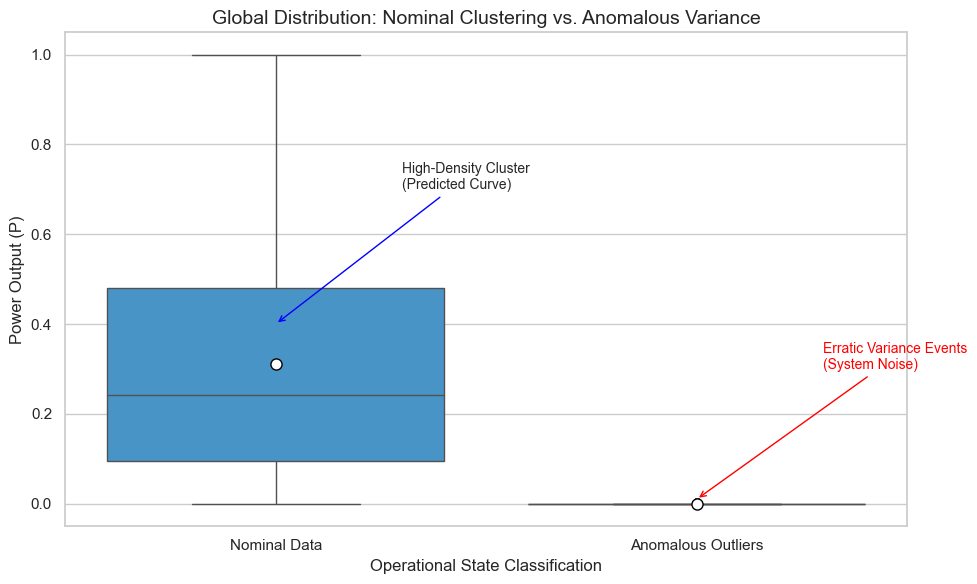

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

def generate_global_outlier_plot(data_path, file_list):
    all_data = []
    
    # 1. Ingest and Combine all 4 raw files
    for file in file_list:
        full_path = os.path.join(data_path, file)
        if os.path.exists(full_path):
            temp_df = pd.read_csv(full_path)
            # Add site identifier for more detail if needed
            temp_df['Site'] = file.split('.')[0]
            all_data.append(temp_df)
    
    df = pd.concat(all_data, ignore_index=True)
    
    # 2. Re-apply the Anomaly Logic for visualization
    # Flagging the "Variance Events" (High Wind + Zero Power)
    df['Status'] = ((df['windspeed_100m'] > 3.5) & (df['Power'] < 0.001)).map({
        False: 'Nominal Data', 
        True: 'Anomalous Outliers'
    })

    # 3. Create the Statistical Visualization
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # Boxplot focusing on the distribution "stretch"
    ax = sns.boxplot(
        x='Status', 
        y='Power', 
        data=df,
        palette=['#3498db', '#e74c3c'], # Professional Blue and Red
        showmeans=True,                # Adds a marker for the Mean
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )

    # 4. Styling for Engineering Documentation
    plt.title('Global Distribution: Nominal Clustering vs. Anomalous Variance', fontsize=14)
    plt.ylabel('Power Output (P)', fontsize=12)
    plt.xlabel('Operational State Classification', fontsize=12)
    
    # Add annotation to explain the heavy skew
    plt.annotate('High-Density Cluster\n(Predicted Curve)', xy=(0, 0.4), xytext=(0.3, 0.7),
                 arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10)
    
    plt.annotate('Erratic Variance Events\n(System Noise)', xy=(1, 0.01), xytext=(1.3, 0.3),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

    plt.tight_layout()
    plt.show()

# --- RUN BLOCK ---
if __name__ == "__main__":
    path = r'C:\projects\ComProg_Lab\EDS_3534_GENITA\data'
    files = ['Location1.csv', 'Location2.csv', 'Location3.csv', 'Location4.csv']
    
    generate_global_outlier_plot(path, files)

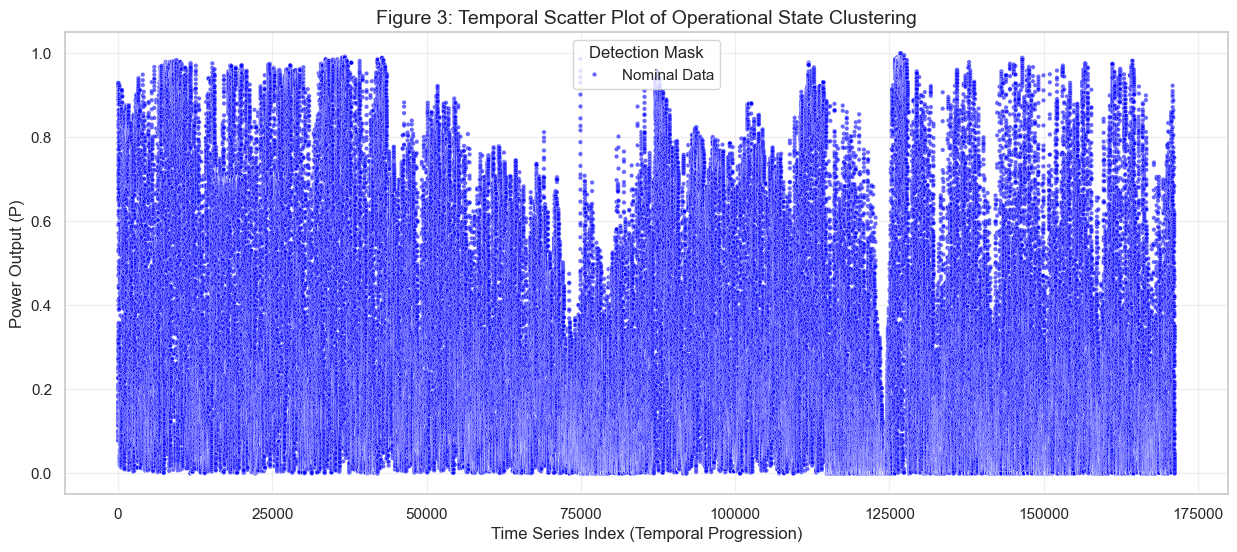

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. First, make sure the 'Status' column is created based on your logic
# This creates the column Seaborn is looking for
df['Status'] = ((df['windspeed_100m'] > 3.5) & (df['Power'] < 0.001)).map({
    False: 'Nominal Data', 
    True: 'Anomalous Outliers'
})

# 2. Now run the plot
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# We use df.index as the x-axis to show temporal progression
sns.scatterplot(data=df, x=df.index, y='Power', hue='Status', 
                palette={'Nominal Data': 'blue', 'Anomalous Outliers': 'red'},
                alpha=0.6, s=10)

plt.title('Figure 3: Temporal Scatter Plot of Operational State Clustering', fontsize=14)
plt.xlabel('Time Series Index (Temporal Progression)', fontsize=12)
plt.ylabel('Power Output (P)', fontsize=12)
plt.legend(title='Detection Mask')
plt.grid(True, alpha=0.3)

plt.show()